# Analisis Data: Brazilian E-Commerce (Olist)

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist**


## Defining Business Questions
1. Bagaimana tren jumlah pesanan dan pendapatan dari waktu ke waktu (misalnya per bulan), serta kategori produk apa yang memberikan kontribusi terbesar terhadap pendapatan?
2. Seberapa sering terjadi keterlambatan pengiriman, wilayah mana yang paling sering mengalami keterlambatan, dan apakah keterlambatan tersebut berpengaruh terhadap penilaian pelanggan?
3. Wilayah mana yang memiliki jumlah pelanggan terbanyak?


## Prepare the Required Libraries
Library berikut dipakai untuk memuat data, membersihkan data, melakukan agregasi, dan membuat visualisasi.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path('data')
DASHBOARD_DIR = Path('dashboard')

currency_formatter = FuncFormatter(lambda x, pos: f'R${x:,.0f}')
percent_formatter = FuncFormatter(lambda x, pos: f'{x:.0%}')


## 1. Data Wrangling
Tahap ini difokuskan untuk memastikan data siap dianalisis. Prosesnya mencakup pemuatan data, pengecekan kualitas, cleaning dasar, dan pembentukan tabel analisis utama.


### 1.1 Gathering Data
Di bagian ini, kita memuat seluruh tabel yang dibutuhkan untuk analisis order, pembayaran, review, pelanggan, dan kategori produk.


In [2]:
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
category_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')

source_tables = {
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'category_translation': category_translation,
    'customers': customers,
    'reviews': reviews,
    'payments': payments,
}

pd.DataFrame(
    {
        'table': list(source_tables.keys()),
        'rows': [df.shape[0] for df in source_tables.values()],
        'columns': [df.shape[1] for df in source_tables.values()],
    }
)


,table,rows,columns
0,orders,99441,8
1,order_items,112650,7
2,products,32951,9
3,category_translation,71,2
4,customers,99441,5
5,reviews,99224,7
6,payments,103886,5


### 1.2 Assessing Data
Kita cek dulu kualitas datanya, terutama untuk melihat apakah ada nilai yang hilang (missing value) atau data yang duplikat.


In [3]:
def summarize_quality(df: pd.DataFrame, name: str, key_cols: list[str] | None = None, top_n: int = 10):
    missing_top = (
        df.isna()
        .sum()
        .loc[lambda s: s > 0]
        .sort_values(ascending=False)
        .head(top_n)
        .rename('missing_values')
        .reset_index()
        .rename(columns={'index': 'column'})
    )

    summary = {
        'table': name,
        'rows': len(df),
        'full_row_duplicates': int(df.duplicated().sum()),
        'columns_with_missing': int(df.isna().any().sum()),
    }
    if key_cols:
        summary['key_duplicates'] = int(df.duplicated(subset=key_cols).sum())

    return summary, missing_top

quality_summaries = []
missing_reports = []

for name, df, key_cols in [
    ('orders', orders, ['order_id']),
    ('customers', customers, ['customer_id']),
    ('order_items', order_items, ['order_id', 'order_item_id']),
    ('payments', payments, ['order_id', 'payment_sequential']),
    ('reviews', reviews, ['review_id']),
    ('products', products, ['product_id']),
]:
    summary, missing_top = summarize_quality(df, name, key_cols=key_cols)
    quality_summaries.append(summary)
    if not missing_top.empty:
        missing_reports.append(missing_top.assign(table=name))

quality_table = pd.DataFrame(quality_summaries).sort_values('rows', ascending=False)
missing_table = pd.concat(missing_reports, ignore_index=True)

quality_table


,table,rows,full_row_duplicates,columns_with_missing,key_duplicates
2,order_items,112650,0,0,0
3,payments,103886,0,0,0
1,customers,99441,0,0,0
0,orders,99441,0,3,0
4,reviews,99224,0,2,814
5,products,32951,0,8,0


In [4]:
missing_table[['table', 'column', 'missing_values']].sort_values(
    ['missing_values', 'table'],
    ascending=[False, True],
)


,table,column,missing_values
3,reviews,review_comment_title,87656
4,reviews,review_comment_message,58247
0,orders,order_delivered_customer_date,2965
1,orders,order_delivered_carrier_date,1783
5,products,product_category_name,610
6,products,product_name_lenght,610
7,products,product_description_lenght,610
8,products,product_photos_qty,610
2,orders,order_approved_at,160
9,products,product_weight_g,2


### 1.3 Cleaning Data
Duplikasi yang benar-benar sama kita hapus, kolom tanggal kita ubah ke format datetime, dan kategori produk yang kosong kita isi dengan label unknown agar tetap ikut terhitung saat agregasi.


In [5]:
def drop_full_duplicates(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    before = len(df)
    cleaned = df.drop_duplicates().copy()
    return cleaned, before - len(cleaned)

orders, removed_orders = drop_full_duplicates(orders)
customers, removed_customers = drop_full_duplicates(customers)
order_items, removed_items = drop_full_duplicates(order_items)
payments, removed_payments = drop_full_duplicates(payments)
reviews, removed_reviews = drop_full_duplicates(reviews)
products, removed_products = drop_full_duplicates(products)

for col in [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
products['product_category_name'] = products['product_category_name'].fillna('unknown')

cleaning_summary = pd.DataFrame(
    {
        'table': ['orders', 'customers', 'order_items', 'payments', 'reviews', 'products'],
        'removed_full_duplicates': [
            removed_orders,
            removed_customers,
            removed_items,
            removed_payments,
            removed_reviews,
            removed_products,
        ],
    }
)

cleaning_summary


,table,removed_full_duplicates
0,orders,0
1,customers,0
2,order_items,0
3,payments,0
4,reviews,0
5,products,0


### 1.4 Data Preparation



In [6]:
items_agg = (
    order_items.groupby('order_id', as_index=False)
    .agg(
        items_count=('order_item_id', 'count'),
        items_price_sum=('price', 'sum'),
        freight_sum=('freight_value', 'sum'),
    )
)

payments_agg = (
    payments.groupby('order_id', as_index=False)
    .agg(
        payment_value_sum=('payment_value', 'sum'),
        payment_installments_max=('payment_installments', 'max'),
    )
)

payment_type_primary = (
    payments.groupby('order_id')['payment_type']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iat[0])
    .reset_index()
    .rename(columns={'payment_type': 'payment_type_primary'})
)

reviews_agg = (
    reviews.groupby('order_id', as_index=False)
    .agg(review_score_mean=('review_score', 'mean'))
)

main_data = (
    orders.merge(customers, on='customer_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(payment_type_primary, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)

for col in ['items_count', 'items_price_sum', 'freight_sum', 'payment_value_sum']:
    main_data[col] = main_data[col].fillna(0)

main_data['order_purchase_month'] = main_data['order_purchase_timestamp'].dt.to_period('M').astype(str)
main_data['delivery_delay_days'] = (
    (main_data['order_delivered_customer_date'] - main_data['order_estimated_delivery_date'])
    .dt.total_seconds()
    .div(86400)
)
main_data['is_delivered'] = main_data['order_status'].eq('delivered')
main_data['is_late'] = main_data['delivery_delay_days'].gt(0)

fallback_revenue = main_data['items_price_sum'] + main_data['freight_sum']
main_data['revenue'] = main_data['payment_value_sum'].where(main_data['payment_value_sum'] > 0, fallback_revenue)

DELIVERED = main_data.loc[main_data['is_delivered']].copy()
DELIVERED_WITH_DELAY = DELIVERED.dropna(subset=['delivery_delay_days']).copy()
DELIVERED_WITH_REVIEW = DELIVERED.dropna(subset=['delivery_delay_days', 'review_score_mean']).copy()

DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
dashboard_cols = [
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_purchase_month',
    'customer_unique_id',
    'customer_city',
    'customer_state',
    'items_count',
    'items_price_sum',
    'freight_sum',
    'payment_value_sum',
    'payment_type_primary',
    'review_score_mean',
    'delivery_delay_days',
    'is_delivered',
    'is_late',
    'revenue',
]
main_data[dashboard_cols].to_csv(DASHBOARD_DIR / 'main_data.csv', index=False)

main_data[dashboard_cols].head()


,order_id,order_status,order_purchase_timestamp,order_purchase_month,customer_unique_id,customer_city,customer_state,items_count,items_price_sum,freight_sum,payment_value_sum,payment_type_primary,review_score_mean,delivery_delay_days,is_delivered,is_late,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1.00,29.99,8.72,38.71,voucher,4.00,-7.11,True,False,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07,af07308b275d755c9edb36a90c618231,barreiras,BA,1.00,118.70,22.76,141.46,boleto,4.00,-5.36,True,False,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1.00,159.90,19.22,179.12,credit_card,5.00,-17.25,True,False,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1.00,45.00,27.20,72.20,credit_card,5.00,-12.98,True,False,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1.00,19.90,8.72,28.62,credit_card,5.00,-9.24,True,False,28.62


## 2. Exploratory Data Analysis (EDA)



### 2.1 Tren jumlah pesanan dan pendapatan per bulan
Agregasi bulanan dipakai untuk melihat pola naik-turun permintaan dan nilai transaksi dari waktu ke waktu.


In [7]:
monthly_trend = (
    DELIVERED.dropna(subset=['order_purchase_timestamp'])
    .groupby('order_purchase_month', as_index=False)
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('revenue', 'sum'),
    )
    .sort_values('order_purchase_month')
)

peak_orders = monthly_trend.loc[monthly_trend['orders'].idxmax(), ['order_purchase_month', 'orders', 'revenue']].to_dict()
peak_revenue = monthly_trend.loc[monthly_trend['revenue'].idxmax(), ['order_purchase_month', 'orders', 'revenue']].to_dict()

monthly_summary = pd.DataFrame([
    {'metric': 'Pesanan tertinggi', **peak_orders},
    {'metric': 'Pendapatan tertinggi', **peak_revenue},
])

monthly_summary


,metric,order_purchase_month,orders,revenue
0,Pesanan tertinggi,2017-11,7289,"1,153,528.05"
1,Pendapatan tertinggi,2017-11,7289,"1,153,528.05"


### 2.2 Kategori produk dengan kontribusi pendapatan terbesar
Untuk menjawab kontribusi kategori, analisis dilakukan pada level item agar setiap produk tetap tercatat pada kategori aslinya.


In [8]:
products_cat = products.merge(category_translation, on='product_category_name', how='left')
products_cat['product_category_name_english'] = products_cat['product_category_name_english'].fillna('unknown')

items_enriched = (
    order_items
    .merge(products_cat[['product_id', 'product_category_name_english']], on='product_id', how='left')
    .merge(orders[['order_id', 'order_status']], on='order_id', how='left')
)

category_revenue = (
    items_enriched.loc[items_enriched['order_status'].eq('delivered')]
    .groupby('product_category_name_english', as_index=False)
    .agg(revenue=('price', 'sum'))
    .sort_values('revenue', ascending=False)
)

category_revenue.head(10)


,product_category_name_english,revenue
43,health_beauty,"1,233,131.72"
71,watches_gifts,"1,166,176.98"
7,bed_bath_table,"1,023,434.76"
65,sports_leisure,"954,852.55"
15,computers_accessories,"888,724.61"
39,furniture_decor,"711,927.69"
49,housewares,"615,628.69"
20,cool_stuff,"610,204.10"
5,auto,"578,966.65"
69,toys,"471,286.48"


### 2.3 Keterlambatan pengiriman, wilayah paling sering terlambat, dan dampaknya pada rating
Bagian ini menjawab tiga hal sekaligus: seberapa sering order terlambat, state mana yang memiliki late rate tertinggi, dan apakah order terlambat menerima rating yang lebih rendah.


In [9]:
late_delivery_summary = pd.DataFrame(
    {
        'metric': ['Total pesanan delivered', 'Pesanan dengan data delay', 'Late delivery rate'],
        'value': [
            len(DELIVERED),
            len(DELIVERED_WITH_DELAY),
            DELIVERED_WITH_DELAY['is_late'].mean(),
        ],
    }
)

late_by_state = (
    DELIVERED_WITH_DELAY.groupby('customer_state', as_index=False)
    .agg(
        total_orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum'),
        late_rate=('is_late', 'mean'),
    )
    .query('total_orders >= 300')
    .sort_values(['late_rate', 'late_orders'], ascending=[False, False])
)

rating_by_delivery_status = (
    DELIVERED_WITH_REVIEW.assign(
        delivery_status=lambda df: np.where(
            df['is_late'],
            'Terlambat',
            'Tepat waktu / lebih cepat',
        )
    )
    .groupby('delivery_status', as_index=False)
    .agg(
        avg_review=('review_score_mean', 'mean'),
        order_count=('order_id', 'nunique'),
    )
    .sort_values('avg_review', ascending=False)
)

late_delivery_summary, late_by_state.head(10), rating_by_delivery_status


(                      metric     value
 0    Total pesanan delivered 96,478.00
 1  Pesanan dengan data delay 96,470.00
 2         Late delivery rate      0.08,
    customer_state  total_orders  late_orders  late_rate
 1              AL           397           95       0.24
 9              MA           717          141       0.20
 16             PI           476           76       0.16
 5              CE          1279          196       0.15
 24             SE           335           51       0.15
 4              BA          3256          457       0.14
 18             RJ         12350         1664       0.13
 13             PA           946          117       0.12
 7              ES          1995          244       0.12
 11             MS           701           81       0.12,
              delivery_status  avg_review  order_count
 0  Tepat waktu / lebih cepat        4.29        88163
 1                  Terlambat        2.57         7661)

### 2.4 Wilayah dengan jumlah pelanggan terbanyak
Terakhir, kita lihat persebaran pelanggan unik per state untuk mengetahui pasar mana yang paling dominan.


In [10]:
customers_by_state = (
    main_data[['customer_unique_id', 'customer_state']]
    .dropna()
    .drop_duplicates()
    .groupby('customer_state', as_index=False)
    .agg(customers=('customer_unique_id', 'nunique'))
    .sort_values('customers', ascending=False)
)

customers_by_state.head(10)


,customer_state,customers
25,SP,40302
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882
23,SC,3534
4,BA,3277
6,DF,2075
7,ES,1964
8,GO,1952


## 3. Data Visualization



### 3.1 Tren jumlah pesanan dan pendapatan per bulan (Q1)



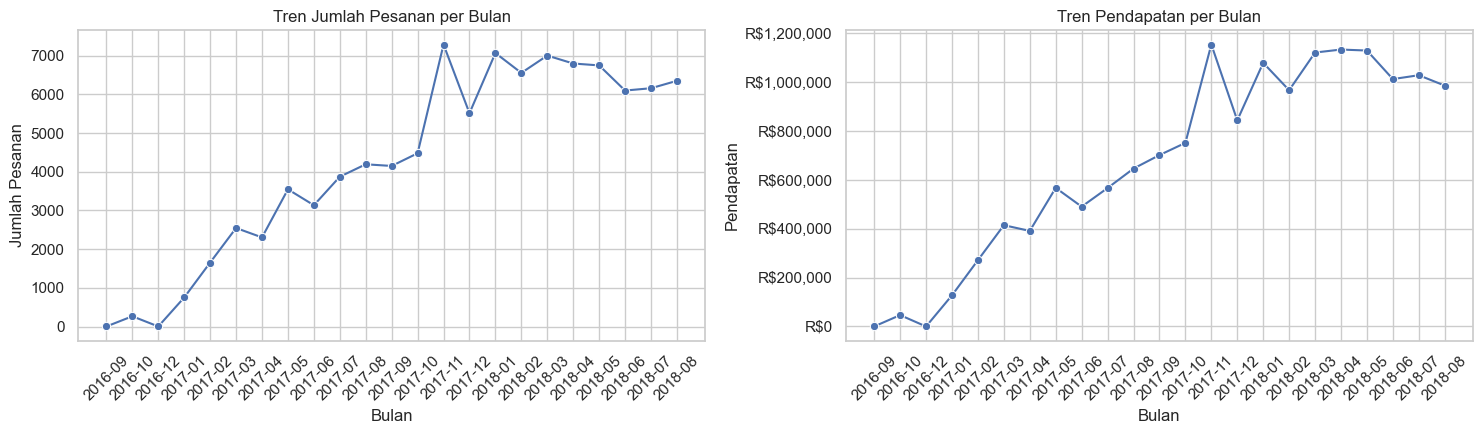

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

sns.lineplot(data=monthly_trend, x='order_purchase_month', y='orders', marker='o', ax=ax[0])
ax[0].set_title('Tren Jumlah Pesanan per Bulan')
ax[0].set_xlabel('Bulan')
ax[0].set_ylabel('Jumlah Pesanan')
ax[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_trend, x='order_purchase_month', y='revenue', marker='o', ax=ax[1])
ax[1].set_title('Tren Pendapatan per Bulan')
ax[1].set_xlabel('Bulan')
ax[1].set_ylabel('Pendapatan')
ax[1].yaxis.set_major_formatter(currency_formatter)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 3.2 Kategori dengan kontribusi pendapatan terbesar (Q1)



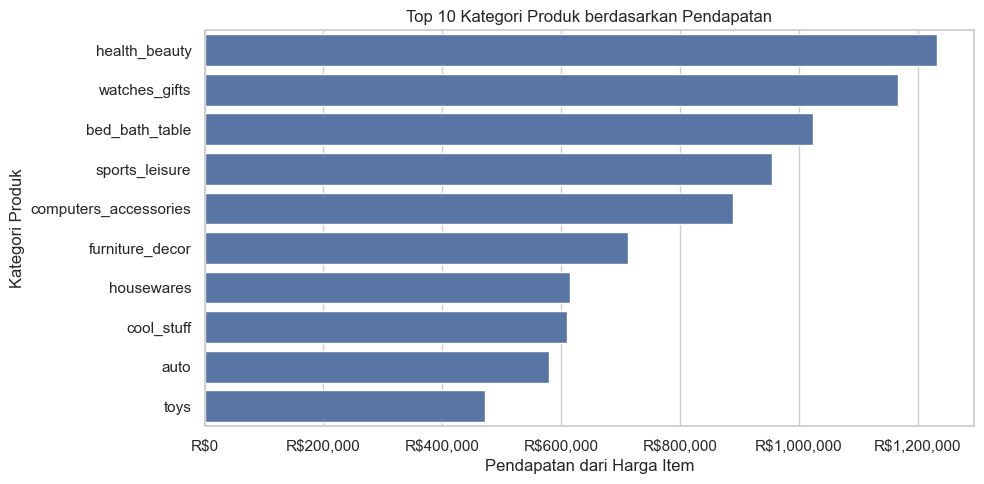

In [12]:
top_categories = category_revenue.head(10).copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_categories, y='product_category_name_english', x='revenue')
plt.title('Top 10 Kategori Produk berdasarkan Pendapatan')
plt.xlabel('Pendapatan dari Harga Item')
plt.ylabel('Kategori Produk')
plt.gca().xaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()


### 3.3 Keterlambatan pengiriman dan kaitannya dengan rating (Q2)



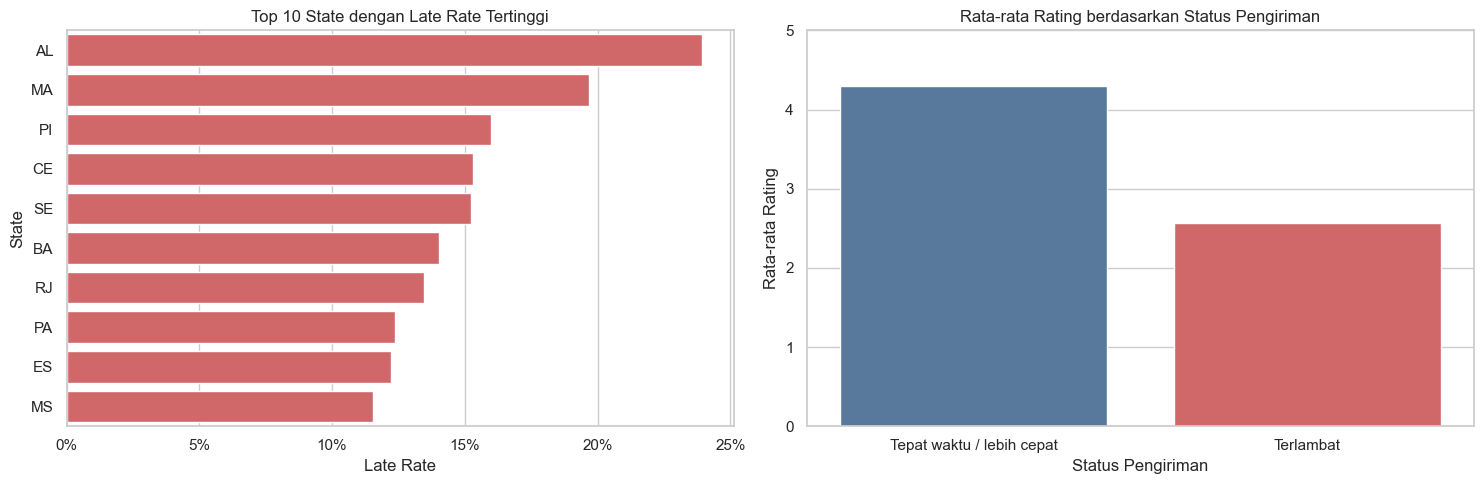

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

top_late_states = late_by_state.head(10).copy()
sns.barplot(
    data=top_late_states,
    y='customer_state',
    x='late_rate',
    color='#E15759',  
    ax=ax[0]
)
ax[0].set_title('Top 10 State dengan Late Rate Tertinggi')
ax[0].set_xlabel('Late Rate')
ax[0].set_ylabel('State')
ax[0].xaxis.set_major_formatter(percent_formatter)

sns.barplot(
    data=rating_by_delivery_status,
    x='delivery_status',
    y='avg_review',
    hue='delivery_status',
    palette={
        'Tepat waktu / lebih cepat': '#4E79A7',  
        'Terlambat': '#E15759',                  
    },
    dodge=False,
    legend=False,
    ax=ax[1],
)
ax[1].set_title('Rata-rata Rating berdasarkan Status Pengiriman')
ax[1].set_xlabel('Status Pengiriman')
ax[1].set_ylabel('Rata-rata Rating')
ax[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()


### 3.4 Wilayah dengan pelanggan terbanyak (Q3)



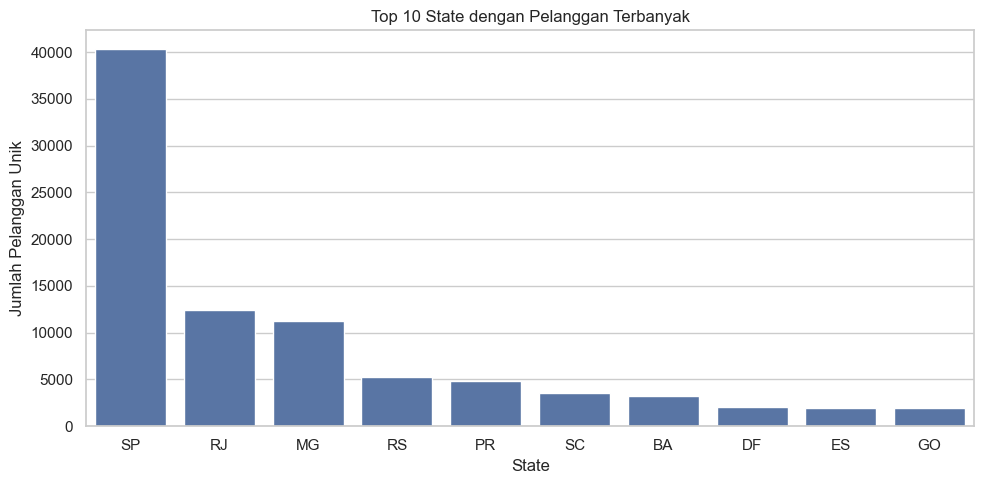

In [14]:
top_customer_states = customers_by_state.head(10).copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_customer_states, x='customer_state', y='customers')
plt.title('Top 10 State dengan Pelanggan Terbanyak')
plt.xlabel('State')
plt.ylabel('Jumlah Pelanggan Unik')
plt.tight_layout()
plt.show()


## Conclusion

Berdasarkan analisis yang dilakukan, terdapat empat temuan utama:

1. **Tren Pesanan dan Pendapatan**  
   Jumlah pesanan dan pendapatan sama-sama mencapai puncak pada **November 2017**, dengan **7.289 pesanan** dan pendapatan sekitar **R$1,15 juta**. Hal ini menunjukkan bahwa volume order sangat berpengaruh terhadap pendapatan.

2. **Kategori dengan Kontribusi Terbesar**  
   Kategori dengan kontribusi pendapatan terbesar adalah **health_beauty**, **watches_gifts**, dan **bed_bath_table**. Artinya, sebagian besar revenue ditopang oleh beberapa kategori yang dominan.

3. **Keterlambatan Pengiriman dan Dampaknya**  
   Sekitar **8,1%** pesanan yang memiliki data pengiriman tercatat terlambat. Beberapa state dengan *late rate* tinggi adalah **AL**, **MA**, dan **PI**. Selain itu, pesanan yang terlambat memiliki rata-rata rating sekitar **2,57**, jauh di bawah pesanan tepat waktu yang berada di kisaran **4,29**.

4. **Distribusi Pelanggan**  
   Pelanggan paling banyak terkonsentrasi di **SP**, disusul **RJ** dan **MG**. Temuan ini menunjukkan bahwa pasar utama Olist masih terpusat pada beberapa state besar.